![](img/banner.png)
%%HTML
<script src="require.js"></script>


# Hidden Markov Models

**Mahmood Amintoosi, Spring 2026**

Computer Science Dept, Ferdowsi University of Mashhad

In [1]:
# Auto-setup when running on Google Colab
import os
if 'google.colab' in str(get_ipython()) and not os.path.exists('/content/SML'):
    !git clone -q https://github.com/fum-cs/SML.git /content/SML
    !pip --quiet install -r /content/SML/requirements_colab.txt
    %cd SML/notebooks

# Global imports and settings
%matplotlib inline
from preamble import *
interactive = False # Set to True for interactive plots
if interactive:
    fig_scale = 0.61
    print_config['font.size'] = 7
    print_config['xtick.labelsize'] = 5
    print_config['ytick.labelsize'] = 5
    plt.rcParams.update(print_config)
else: # For printing
    fig_scale = 0.28
    plt.rcParams.update(print_config)

import seaborn as sns    

## Hidden Markov Models (HMMs)

Hidden Markov Models are widely used in various fields, including natural language processing, speech recognition, and bioinformatics. They are probabilistic models that capture sequences of observations (or symbols) generated by an underlying hidden state process. 
A good source for HMM is [Appendix A of Speech and Language Processing](https://web.stanford.edu/~jurafsky/slp3/A.pdf), by Dan Jurafsky and James H. Martin.

Here are the key components of an HMM:

1. **States**: An HMM consists of a set of hidden states. Each state represents a different situation or condition. For example, in part-of-speech tagging, states could correspond to different parts of speech (e.g., noun, verb, adjective).

2. **Observations (Emissions)**: At each time step, the HMM emits an observation (symbol) based on the current hidden state. These observations can be words, phonemes, or any other relevant symbols.

3. **Transition Probabilities**: HMMs model how the hidden states transition from one to another. Transition probabilities represent the likelihood of moving from one state to another.

4. **Emission Probabilities**: Each hidden state has associated emission probabilities for generating specific observations. These probabilities indicate how likely an observation is given the current state.

The following figure shows an HMM with 4 states which can emit 2 discrete symbols $o_1$ or $o_2$.
$a_{ij}$ is the probability to transition from state $S_i$ to state $S_j$.
$b_j(o_k)$ is the probability to emit symbol $o_k$ in state $S_j$.
In this particular HMM, states can only reach themselves or the adjacent state.

![HMM Model](img/08_HMM_Model.png)

## HMM Parameters

The mathematical notation of HMM parameters is as follows:

1. **Model parameters**
   - $\lambda = (A, B, \pi)$: The complete set of model parameters, comprising the state
     transition probabilities, emission probabilities, and initial state probabilities.

2. **State set**
   - $S = \{s_1, \dots, s_N\}$: The set of all possible hidden states.

3. **Observation set**
   - $V = \{v_1, \dots, v_M\}$: The set of all possible observations (the vocabulary).

4. **State transition matrix**
   - $A \in \mathbb{R}^{N \times N}$, where
     $a_{ij} = P(q_t = s_j \mid q_{t-1} = s_i)$
     is the probability of transitioning from state $s_i$ to state $s_j$.

   > **Notation:** We often write state $s_i$ simply as $i$, so the above becomes
   > $a_{ij} = P(q_t = j \mid q_{t-1} = i)$.

5. **Emission probabilities**
   - $B$: The emission probability function, where
     $b_j(o_t) = P(o_t \mid q_t = j)$
     is the probability of observing $o_t$ while the system is in state $j$.
     For discrete observations $B$ is a matrix; for continuous observations it is
     typically a Gaussian (or GMM).

6. **Initial state probabilities**
   - $\pi$, where $\pi_i = P(q_1 = i)$ is the probability of the system starting
     in state $i$.

7. **Observation sequence**
   - $O = o_1\, o_2\, \cdots\, o_T$: The observed sequence of length $T$.

---

## The Three Fundamental Problems of HMMs

Every practical application of HMMs reduces to one of three core problems.

### Problem 1 — Likelihood
**Task:** Given an HMM $\lambda = (A, B, \pi)$ and an observation sequence $O$,
compute the likelihood $P(O \mid \lambda)$.

Naively, this requires summing over all $N^T$ possible hidden state sequences, which
is exponential in $T$. The standard solution is the **Forward Algorithm**: a dynamic
programming method that computes $P(O \mid \lambda)$ in $O(N^2 T)$ time by defining
the *forward variable* $\alpha_t(j) = P(o_1, \dots, o_t, q_t = j \mid \lambda)$ and
building it up recursively. A numerically symmetric companion, the **Backward
Algorithm**, defines $\beta_t(i) = P(o_{t+1}, \dots, o_T \mid q_t = i, \lambda)$ and
is required for Problem 3.

### Problem 2 — Decoding
**Task:** Given an observation sequence $O$ and an HMM $\lambda = (A, B, \pi)$, find
the most probable hidden state sequence
$Q^* = \arg\max_Q P(Q \mid O, \lambda)$.

The standard solution is the **Viterbi Algorithm**: a dynamic programming method that
finds the globally optimal state sequence in $O(N^2 T)$ time. It defines the *Viterbi
variable* $\delta_t(j) = \max_{q_1,\dots,q_{t-1}} P(q_1,\dots,q_{t-1}, q_t=j,
o_1,\dots,o_t \mid \lambda)$ and traces back the best path through a back-pointer
matrix.

### Problem 3 — Learning
**Task:** Given an observation sequence $O$ (or a set of sequences) and the number of
states $N$, estimate the parameters $\lambda = (A, B, \pi)$ that maximise
$P(O \mid \lambda)$.

This is solved by the **Baum–Welch Algorithm**, a special case of the EM algorithm.
It iterates between:
- **E-step:** compute the *forward–backward variables* $\alpha$, $\beta$, and from
  them the occupation counts $\gamma_t(i)$ and transition counts $\xi_t(i,j)$;
- **M-step:** re-estimate $A$, $B$, and $\pi$ from those counts.

The procedure is guaranteed to converge to a local maximum of the likelihood. Because
the objective is non-convex, multiple random restarts are advisable in practice.

# Problem 1 — Likelihood

Given an HMM $\lambda = (A, B, \pi)$ and an observation sequence
$O = o_1\, o_2\, \cdots\, o_T$, we want to compute $P(O \mid \lambda)$.

The most straightforward approach is to sum over all possible hidden state sequences:

$$P(O \mid \lambda) = \sum_{Q} P(O \mid Q, \lambda)\, P(Q \mid \lambda)$$

where the sum runs over all $N^T$ possible sequences $Q = q_1 q_2 \cdots q_T$.
Each term factorises cleanly thanks to the Markov assumption and the conditional
independence of observations:

$$P(O \mid Q, \lambda)\, P(Q \mid \lambda)
= \pi_{q_1} \prod_{t=1}^{T} b_{q_t}(o_t) \prod_{t=2}^{T} a_{q_{t-1} q_t}$$

The problem is computational: even for modest values such as $N = 6$ states and
$T = 100$ time steps, the number of sequences is $6^{100} \approx 10^{77}$ — far
beyond any enumeration.

## The Forward Algorithm

The key observation is that the naïve sum recomputes the same sub-sequences
exponentially many times. This is the same situation we encounter in many dynamic
programming problems: overlapping subproblems that can be solved once and reused.

We define the **forward variable**:

$$\alpha_t(j) = P(o_1, o_2, \dots, o_t,\; q_t = j \mid \lambda)$$

which is the joint probability of having seen the first $t$ observations *and* being
in state $j$ at time $t$. This can be computed recursively:

**Initialisation** $(t=1)$:

$$\alpha_1(j) = \pi_j\, b_j(o_1), \qquad 1 \le j \le N$$

**Recursion** $(t = 2, \dots, T)$:

$$\alpha_t(j) = \left[\sum_{i=1}^{N} \alpha_{t-1}(i)\, a_{ij}\right] b_j(o_t)$$

**Termination**:

$$P(O \mid \lambda) = \sum_{j=1}^{N} \alpha_T(j)$$

The recursion step has a natural reading: to be in state $j$ at time $t$ and have
produced $o_t$, the system must have been in *some* state $i$ at time $t-1$
(with probability $\alpha_{t-1}(i)$), transitioned to $j$ (with probability $a_{ij}$),
and emitted $o_t$ (with probability $b_j(o_t)$).

## Complexity and Connection to Previous Ideas

The Forward Algorithm reduces the cost from $O(N^T)$ to $O(N^2 T)$ — an enormous
gain. The structure is identical in spirit to what you have seen before: instead of
summing over all combinations explicitly, we propagate a compact *summary* (the vector
$\alpha_t$) forward in time, updating it step by step.

Notice also the connection to the **Naïve Bayes** and **Bayesian Decision Theory**
frameworks from earlier in the course. At each step we are essentially computing a
conditional probability by combining a prior (the transition) with a likelihood (the
emission) — the same Bayesian product that appeared throughout the course, now applied
sequentially across time.

# Problem 2 — Decoding

Given an observation sequence $O = o_1\, o_2\, \cdots\, o_T$ and an HMM
$\lambda = (A, B, \pi)$, we want to find the most probable hidden state sequence:

$$Q^* = \underset{Q}{\arg\max}\ P(Q \mid O, \lambda)$$

We already know how to compute $P(O \mid \lambda)$ using the Forward Algorithm.
One might think we could simply pick, at each time step $t$, the state $j$ that
maximises $\alpha_t(j)$ — choosing the locally most probable state at every step.
However, this greedy approach does not guarantee a *globally* consistent sequence:
the state chosen at time $t$ may be unreachable from the state chosen at time $t-1$,
or may make the states at $t+1$ very unlikely. We need an algorithm that considers
the full sequence jointly.

## The Viterbi Algorithm

The solution is the **Viterbi Algorithm**, a dynamic programming method closely
related to the Forward Algorithm. Instead of *summing* over all paths leading to
state $j$ at time $t$, it takes the *maximum*:

$$v_t(j) = \max_{q_1, \dots, q_{t-1}}\ P(q_1, \dots, q_{t-1},\, q_t = j,\,
o_1, \dots, o_t \mid \lambda)$$

This single change — replacing $\sum$ with $\max$ — is the entire difference
between the Forward Algorithm and Viterbi. The rest of the structure,
initialisation, recursion, and termination, follows the same dynamic programming
template, with an added back-pointer matrix to recover the optimal path at the end.


The Viterbi algorithm aims to find the most likely sequence of hidden states $Q = q_1 q_2 ... q_T$ that maximizes the probability $P(O,Q|\lambda)$. 

The algorithm uses the following recurrence relation:

$$v_t(j) = \max_{1 \leq j \leq N} v_{t-1}(i) a_{ij} b_i(o_t)$$

where $v_t(j)$ represents the maximum probability of the most likely sequence of states ending in state $i$ at time $t$ and observing the partial sequence $o_1o_2...o_t$.

The Viterbi algorithm can be summarized as follows:

1. Initialization:
   - $v_1(j) = \pi_j b_j(o_1)$, for $1 \leq j \leq N$
   - $bt_1(i) = 0$

2. Recursion:
   - $v_t(j) = \max_{1 \leq i \leq N} v_{t-1}(i) a_{ij} b_j(o_t)$, for $2 \leq t \leq T$ and $1 \leq j \leq N$
   - $bt_t(j) = \arg\max_{1 \leq i \leq N} v_{t-1}(i) a_{ij}b_j(o_t)$, for $1 \leq t \leq T$ and $1 \leq i \leq N$

3. Termination:
   - $P^* = \max_{1 \leq i \leq N} v_T(i)$
   - $q_T^* = \arg\max_{1 \leq i \leq N} v_T(i)$

4. Backtracking:
   - $q_t^* = bt_{t+1}(q_{t+1}^*)$, for $t = T-1, T-2, ..., 1$

The final result is the most likely sequence of hidden states $Q^* = q_1^* q_2^* ... q_T^*$ and the maximum probability $P^*$.


The trellis diagram is a visual representation of the Viterbi algorithm, which is used to find the most likely sequence of hidden states (also known as the Viterbi path) given an observed sequence of emissions in a Hidden Markov Model (HMM).

![HMM](img/08_HMM_Model.png)

The **trellis diagram** depicts the evolution of the HMM over time, with each column representing a time step, and each row representing a possible state of the HMM. The nodes in the diagram represent the states, and the edges represent the transitions between states.

![Trellis Diagram](img/08_HMM_Trellis.png)
Figure: Trellis of the observation sequence $o_1$,$o_2$,$o_2$ for the above HMM. The thick arrows indicate the most probable transitions. As an example, the transition between state $s_1$ at time t=2 and state $s_4$ at time t=3 has probability $\alpha_2(1)a_{14}b_4(o_2)$, where $\alpha_t(i)$ is the probability to be in state $s_i$ at time t.


The trellis diagram is constructed as follows:

1. The first column represents the initial state of the HMM at time $t=1$. The nodes in this column correspond to the possible states of the HMM, and they are labeled with the state names ($s_1, s_2, s_3, s_4$).

2. The subsequent columns represent the HMM at subsequent time steps ($t=2$, $t=3$, etc.). The nodes in these columns also correspond to the possible states of the HMM, and they are connected to the nodes in the previous column by edges that represent the state transitions.

3. The thickness of the edges represents the probability of the transition. The thick edges indicate the most likely transitions, as determined by the Viterbi algorithm.

In the example, the trellis diagram shows the evolution of the HMM for the observed sequence $o_1, o_2, o_2$. The Viterbi algorithm is used to find the most likely sequence of hidden states that could have generated this observed sequence. The thick edges in the diagram represent the Viterbi path, which is the sequence of states that has the highest probability of producing the observed sequence.

The caption of the trellis diagram provides an example of how the transition probability between two states is calculated. Specifically, the transition probability between state S1 at time $t=2$ and state S4 at time $t=3$ is given by the expression $\alpha_2(1)a_{14}b_4(o_2)$, where:

- $\alpha_2(1)$ is the probability of being in state $s_1$ at time $t=2$
- $a_{14}$ is the transition probability from state $s_1$ to state $s_4$
- $b_4(o_2)$ is the probability of observing the symbol $o_2$ in state $s_4$

The trellis diagram is a valuable tool for visualizing the Viterbi algorithm and understanding the most likely sequence of hidden states that could have generated the observed sequence in an HMM.


## Dynamic Programming

Dynamic programming is a powerful technique for solving problems by breaking them down into smaller, overlapping subproblems. It's widely used in various fields, including computer science, optimization, and image processing. One intriguing application of dynamic programming is **seam carving**. Seam carving is used in content-aware image resizing, in which, its algorithm is very similar to Viterbi algorithm.

## Content-Aware Image Resizing
Content-aware image resizing aims to change the width or height of an image while preserving its essential features. Traditional methods like cropping and scaling have limitations, often resulting in loss of important content or visible artifacts. Seam carving offers an elegant solution by identifying and removing low-energy seams from the image.

### What Are Seams?
In the context of seam carving, a **seam** is a connected path of pixels that spans the entire height or width of the image. The goal is to find the lowest-energy seam (i.e., the least interesting part of the image) and remove it. Seam carving ensures that the removed seam doesn't disrupt the overall visual coherence.

### Seam Carving Process
1. **Energy Calculation**: First, we compute the energy of each pixel in the image. Energy represents the importance of a pixel based on its color gradients. Higher energy corresponds to more visually significant regions.

2. **Dynamic Programming**: Seam carving uses dynamic programming to find the optimal seam. For vertical resizing (reducing width), we find the seam with the minimum cumulative energy from top to bottom. The seam moves left or right by at most one pixel in each row.

3. **Seam Removal**: Once we identify the lowest-energy seam, we remove it by shifting the remaining pixels to close the gap. This process is repeated until the desired image width is achieved.

### Example
Consider the [following image](https://www.ulfdittmer.com/imagej/seam-carving.html); Seam carving identifies the lowest-energy seam, which typically runs through less interesting areas. By removing this seam, we resize the image without sacrificing essential details.

![Seam-Carving Image](img/seam-carving.jpg)

See these pages:

- [Implementing Seam Carving with Python](https://karthikkaranth.me/blog/implementing-seam-carving-with-python/), by Karthik Karanth
- [Intro to the Seam Carving Algorithm](https://ben-tanen.com/projects/2020/10/08/seam-carving-pt1.html), by Ben Tanen

**Dynamic programming** plays a crucial role in both seam carving and the Viterbi algorithm. While seam carving focuses on content-aware image resizing, the Viterbi algorithm is used for decoding Hidden Markov Models (HMMs).

By looking at seam carving through the lens of a horizontal state lattice, we can uncover a direct structural dual between image processing and probabilistic sequence estimation.

### Feature Comparison

| Feature / Concept | Horizontal Seam Carving | Hidden Markov Model (HMM) & Viterbi |
|------------------|------------------------|-------------------------------------|
| Horizontal Position (j) | Column index across the grid | Time step / Observation Sequence index (t) |
| Vertical Position (i) | Row index (pixel tracking height) | Hidden States (Sᵢ) |
| Local Cost / Penalty | Pixel Energy Value E(i, j) | Log Emission Probability −log 𝑃(𝑂ₜ∣Sᵢ) |
| Adjacency Constraint | Spatial pixel connectivity (± 1 row variation) | Transition Matrix Penalties −log 𝑃(Sₜ∣Sₜ₋₁) |
| Optimization Goal | Minimize global cumulative path energy sum | Maximize global joint path probability product |



## Visualizing the Dynamic Programming Steps

To bridge the gap between static code and algorithmic intuition, we can run the calculation over a tiny 5×5 toy matrix. 

In [2]:
from matplotlib.animation import FuncAnimation
# 1. Setup a distinct 5x5 Toy Matrix for clarity
np.random.seed(42)
toy_energy = np.random.randint(1, 9, size=(5, 5))

# 2. Compute the horizontal forward progress history
r, c = toy_energy.shape
M_history = [toy_energy.copy().astype(float)]
M = toy_energy.copy().astype(float)
backtrack = np.zeros_like(toy_energy, dtype=int)

for j in range(1, c):
    for i in range(r):
        top, bottom = max(0, i - 1), min(r - 1, i + 1)
        idx = np.argmin(M[top:bottom + 1, j - 1])
        best_prev_i = top + idx
        M[i, j] += M[best_prev_i, j - 1]
        backtrack[i, j] = best_prev_i
    M_history.append(M.copy())

In [3]:
# 3. Extract the Viterbi-style path
curr_i = np.argmin(M[:, -1])
toy_path = [(curr_i, c - 1)]
for j in range(c - 1, 0, -1):
    curr_i = backtrack[curr_i, j]
    toy_path.append((curr_i, j - 1))
toy_path = np.array(toy_path[::-1])

# 4. Generate the JupyterBook HTML5 Animation Loop
fig, ax = plt.subplots(figsize=(6, 4.5))

def update_animation(frame):
    ax.clear()
    if frame < c:
        sns.heatmap(M_history[frame], annot=True, cmap="Blues", cbar=False, fmt=".0f", ax=ax, annot_kws={"size": 12})
        ax.set_title(f"Forward Pass: Processing Time Step t = {frame}", fontsize=11, weight='bold')
    else:
        sns.heatmap(M_history[-1], annot=True, cmap="Blues", cbar=False, fmt=".0f", ax=ax, annot_kws={"size": 12})
        ax.plot(toy_path[:, 1] + 0.5, toy_path[:, 0] + 0.5, color="red", marker="o", linewidth=4, markersize=8, label="Viterbi Seam")
        ax.set_title("Backtracking: Optimal Path Decoded!", fontsize=11, color="red", weight='bold')
        ax.legend(loc="upper left")
        
    ax.set_ylabel("HMM Hidden States (Rows)")
    ax.set_xlabel("Observations / Time Steps (Columns)")

ani = FuncAnimation(fig, update_animation, frames=c+1, interval=1500, repeat=True)
plt.close()

# Display embedded video loop inside JupyterBook
# HTML(ani.to_html5_video())
HTML(ani.to_jshtml())

## Seam Carving Algorithm

**Energy Calculation (Emission Dual):**
- Compute the local energy of each pixel in the image using gradients
- High-energy pixels correspond to edges (crucial features), while low-energy pixels represent uniform background noise
- This step behaves exactly like evaluating localized Emission Matrices to determine state costs at a specific slice

**The Trellis Array / Dynamic Programming Table:**
- Create a cumulative dynamic programming table M with dimensions matching the image space
- Initialize the base boundary vector using the initial slice costs (the structural dual of Initial State Probabilities π)

**Optimal Path Tracking (Forward Pass):**
- Move through the trellis layer by layer
- For each coordinate, compute the cumulative energy by evaluating the allowed neighbor transitions from the previous step
- Update the current cell with the minimum global path cost discovered so far

**Decoding Sequence (Viterbi Backtracking):**
- Identify the single element containing the minimum total energy value along the final terminal layer
- Trace backward sequentially to decode the globally optimal hidden path
- Drop the selected path coordinates to collapse the grid dimensions smoothly


## Seam Carving Algorithm

The algorithm consists of three phases, each mapping directly onto a component of
the Viterbi algorithm.

---

### Phase 1 — Energy Calculation  (`calc_energy`)
*HMM analogue: computing emission costs $-\log P(o_t \mid S_i)$ for every cell*

$$E(i,j) = \left|\frac{\partial I}{\partial x}\right| + \left|\frac{\partial I}{\partial y}\right|$$

```
INPUT:  RGB image of shape (r, c, 3)
OUTPUT: energy map of shape (r, c)

1. Convert image to grayscale
2. Compute horizontal gradient Ix and vertical gradient Iy
   using numpy.gradient on the grayscale image
3. Return |Ix| + |Iy|
```

---

### Phase 2 — Forward Pass  (`minimum_vertical_seam`)
*HMM analogue: the Viterbi recursion — filling the trellis column by column*

**Initialisation** (row $i = 0$):

$$M(0,\, j) = E(0,\, j), \qquad 0 \le j < c$$

**Recursion** (rows $i = 1, \dots, r-1$):

$$M(i,\, j) = E(i,\, j) +
  \min_{k \,\in\, \mathcal{N}(j)}\, M(i-1,\, k)$$

$$bt(i,\, j) = \arg\min_{k \,\in\, \mathcal{N}(j)}\, M(i-1,\, k)$$

where $\mathcal{N}(j) = \{\max(0,\, j-1),\ j,\ \min(c-1,\, j+1)\}$
is the set of allowed predecessors (at most three neighbours).

```
INPUT:  RGB image of shape (r, c, 3)
OUTPUT: cumulative energy matrix M  (r, c)
        back-pointer matrix bt       (r, c)  [stores column index of chosen predecessor]

1. Compute energy map E = calc_energy(img)
2. Initialise M = copy of E  (first row already correct)
3. Initialise bt = zeros (r, c)

4. FOR i = 1 TO r-1:
     FOR j = 0 TO c-1:
         left  = max(0, j-1)            // left boundary guard
         right = j+2                    // slice end (exclusive), at most j+1
         
         idx        = argmin( M[i-1, left : right] )   // index within the slice
         best_col   = left + idx                        // absolute column index
         
         M[i, j]   += M[i-1, best_col]
         bt[i, j]   = best_col

5. RETURN M, bt
```

> **Viterbi parallel:** `M[i, j]` plays the role of $v_t(j)$ (accumulated best score),
> and `bt[i, j]` plays the role of $bt_t(j)$ (back-pointer to the best predecessor).
> Rows correspond to time steps; columns correspond to hidden states.

---

### Phase 3 — Backtracking  (`find_optimal_vertical_seam`)
*HMM analogue: recovering $Q^*$ by following back-pointers from $q_T^*$ to $q_1^*$*

```
INPUT:  cumulative matrix M  (r, c)
        back-pointer matrix bt (r, c)
OUTPUT: seam — list of (row, col) pairs of length r

1. j = argmin( M[r-1, :] )      // Termination: best final state
2. seam = []

3. FOR i = r-1 DOWNTO 0:
       seam.append( (i, j) )
       j = bt[i, j]             // Follow back-pointer to predecessor column

4. REVERSE seam
5. RETURN seam
```

---

### Phase 4 — Seam Removal  (`carve_column`)
*No HMM analogue — this is the image-specific step that applies the decoded path*

```
INPUT:  RGB image (r, c, 3)
OUTPUT: RGB image (r, c-1, 3)  [one column narrower]

1. Compute M, bt = minimum_vertical_seam(img)
2. seam = find_optimal_vertical_seam(M, bt)
3. Build boolean mask of shape (r, c), initialised to True
4. FOR (i, j) IN seam:
       mask[i, j] = False
5. Expand mask to 3 channels
6. Return img filtered by mask, reshaped to (r, c-1, 3)
```

---

### Horizontal Carving  (`crop_r`)
*HMM parallel: time flows left-to-right; transposing maps image rows → hidden states*

```
INPUT:  RGB image (r, c, 3),  num_seams
OUTPUT: RGB image (r - num_seams, c, 3)

1. Transpose image:  img_t = img.transpose(1, 0, 2)   // shape becomes (c, r, 3)
2. img_t = crop_c(img_t, num_seams)                   // carve vertical seams on the transposed image
3. Return img_t.transpose(1, 0, 2)                    // restore original axis order
```

> After transposition, image **columns become rows** and image **rows become columns**.
> Carving a vertical seam on the transposed image is therefore equivalent to carving
> a horizontal seam on the original — exactly as the Viterbi trellis reads left to
> right through time.

---

### Full Pipeline Summary

```
crop_c(img, n):                      
  REPEAT n times:                    
    E  ← calc_energy(img)            
    M, bt ← forward_pass(E)          
    seam ← backtrack(M, bt)
    img  ← remove_seam(img, seam)
  RETURN img
```

### Seam-Carving Implementation

The core algorithm functions below natively execute vertical seam carving. To perform horizontal seam carving (which mirrors the standard left-to-right temporal progression of a Viterbi trellis), we simply pass an axis-transposed matrix configuration using `.transpose(1, 0, 2)`.

In [4]:
"""
This is a combination of Karthik Karanth and my implementation for seam carving, polished by Gemini
"""

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from skimage.color import rgb2gray
from skimage.io import imread

def calc_energy(img):
    """
    Calculates spatial gradient energy map.
    Educational note: Lower energy values act like higher emission probabilities.
    """
    Ix, Iy = np.gradient(rgb2gray(img))
    return np.abs(Ix) + np.abs(Iy)

def minimum_vertical_seam(img):
    """
    Computes cumulative energy matrix M and backtrack grid for vertical paths.
    Think of this function as constructing a forward Viterbi trellis calculation.
    """
    r, c, _ = img.shape
    energy_map = calc_energy(img)

    M = energy_map.copy().astype(float)
    backtrack = np.zeros_like(M, dtype=np.int32)

    # Forward Pass: Row-by-row (Top to Bottom step progression)
    for i in range(1, r):
        for j in range(0, c):
            left_most_col = max(0, j - 1)
            
            # Transition constraint: select minimum energy neighbor directly above
            idx = np.argmin(M[i - 1, left_most_col : j + 2])
            backtrack[i, j] = left_most_col + idx
            M[i, j] += M[i - 1, left_most_col + idx]

    return M, backtrack

def find_optimal_vertical_seam(M, backtrack):
    """Traces back from bottom-to-top to decode the optimal column index path sequence."""
    r, c = M.shape
    j = np.argmin(M[-1])  # Step 1: Find global minimum at the terminal layer
    seam = []

    # Step 2: Backtrack sequence from terminal layer back to initialization layer
    for i in reversed(range(r)):
        seam.append((i, j))
        j = backtrack[i, j]

    seam.reverse()
    return seam

def carve_column(img):
    """Removes one vertical seam from the image, reducing width by 1 pixel."""
    r, c, ch = img.shape
    M, backtrack = minimum_vertical_seam(img)
    mask = np.ones((r, c), dtype=bool)

    seam_indices = find_optimal_vertical_seam(M, backtrack)
    for i, j in seam_indices:
        mask[i, j] = False

    # Apply mask over all color channels and drop one column slice cleanly
    mask_3d = np.stack([mask] * ch, axis=2)
    return img[mask_3d].reshape((r, c - 1, ch))

def crop_c(img, num_seams):
    """Reduces image width by carving multiple vertical seams sequentially."""
    for _ in range(min([num_seams, img.shape[1] - 1])):
        img = carve_column(img)
    return img

# =========================================================================
# THE VITERBI BRIDGE: Horizontal Seam Carving via Simple Axis Transposition
# =========================================================================

def crop_r(img, num_seams):
    """
    Reduces image height by transposing it and applying vertical carving.
    Flipping axes maps standard image rows into HMM Hidden States, and
    image columns into sequential observation Time Steps (t).
    """
    # Transpose Shape: (Rows, Columns, Channels) -> (Columns, Rows, Channels)
    img_t = img.transpose(1, 0, 2)
    img_t = crop_c(img_t, num_seams)
    # Transpose back to original visual orientation
    return img_t.transpose(1, 0, 2)

# usage:
# seam_indices = find_optimal_vertical_seam(M, backtrack)
# Now seam_indices contains the optimal path as a list of (i, j) indices

### Executing Vertical Seam Carving on Real Images

**Horizontal Seam Carving**

*Path Overlay:* Highlighting the Optimal Trellis Sequence (optimum seam) in Red

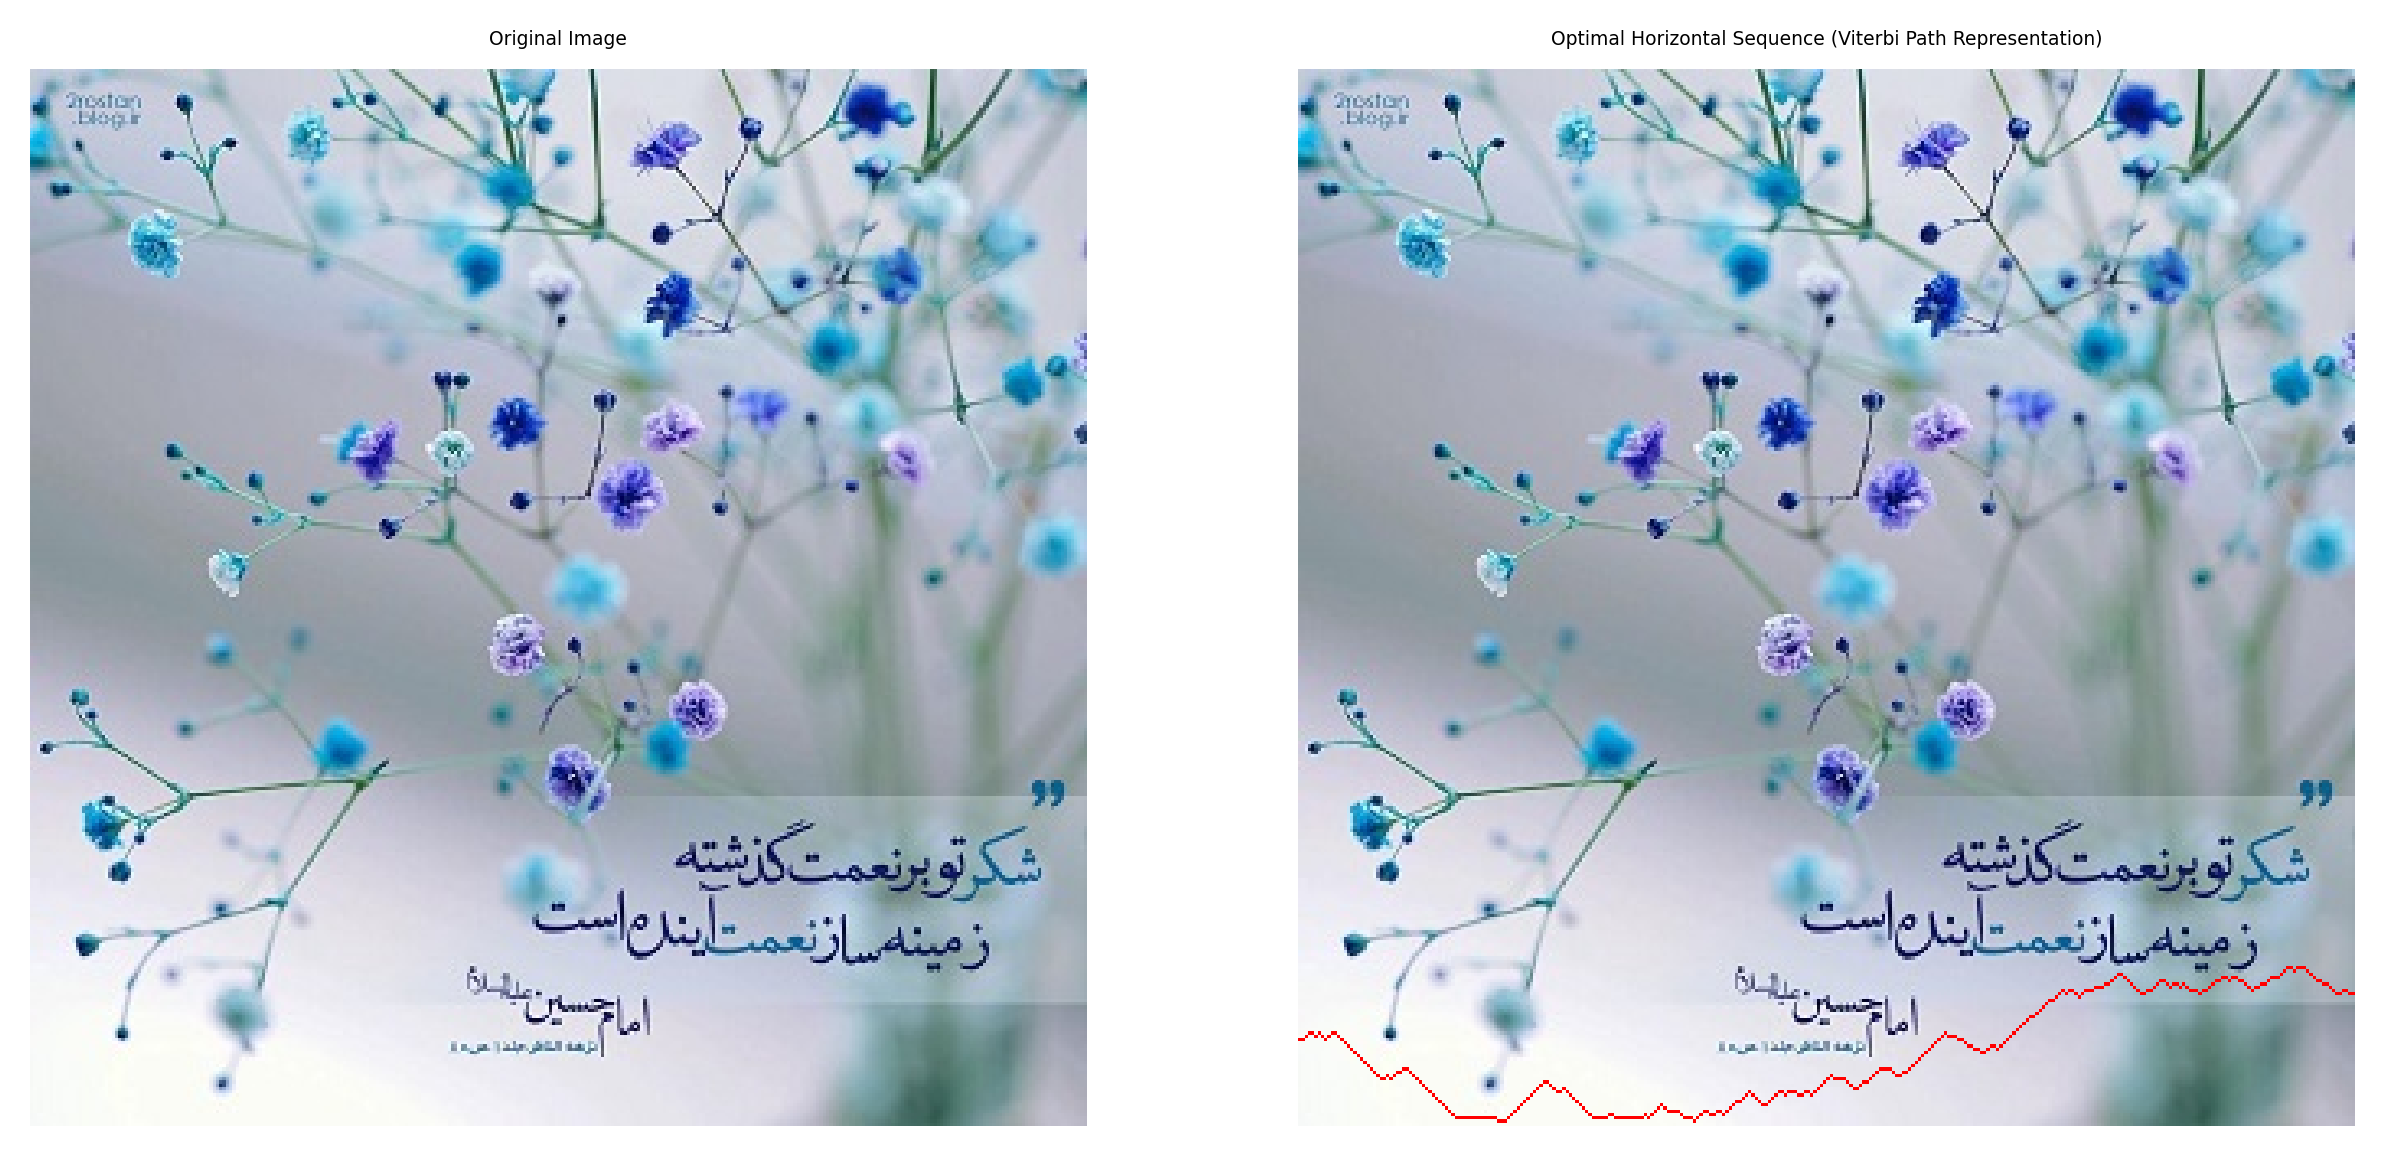

In [5]:
in_filename = "img/thanks.jpg"
img = imread(in_filename)

# Pass transposed array to calculate the path coordinates
img_t = img.transpose(1, 0, 2)
M, backtrack = minimum_vertical_seam(img_t)
seam_indices = find_optimal_vertical_seam(M, backtrack)

# Color the optimal path red on a copy of the transposed array
im_hs_t = img_t.copy()
for i, j in seam_indices:
    im_hs_t[i, j] = (255, 0, 0)

# Return the image to its original layout for display
im_hs = im_hs_t.transpose(1, 0, 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Optimal Horizontal Sequence (Viterbi Path Representation)")
plt.imshow(im_hs)
plt.show()

**Vertical Seam Carving**

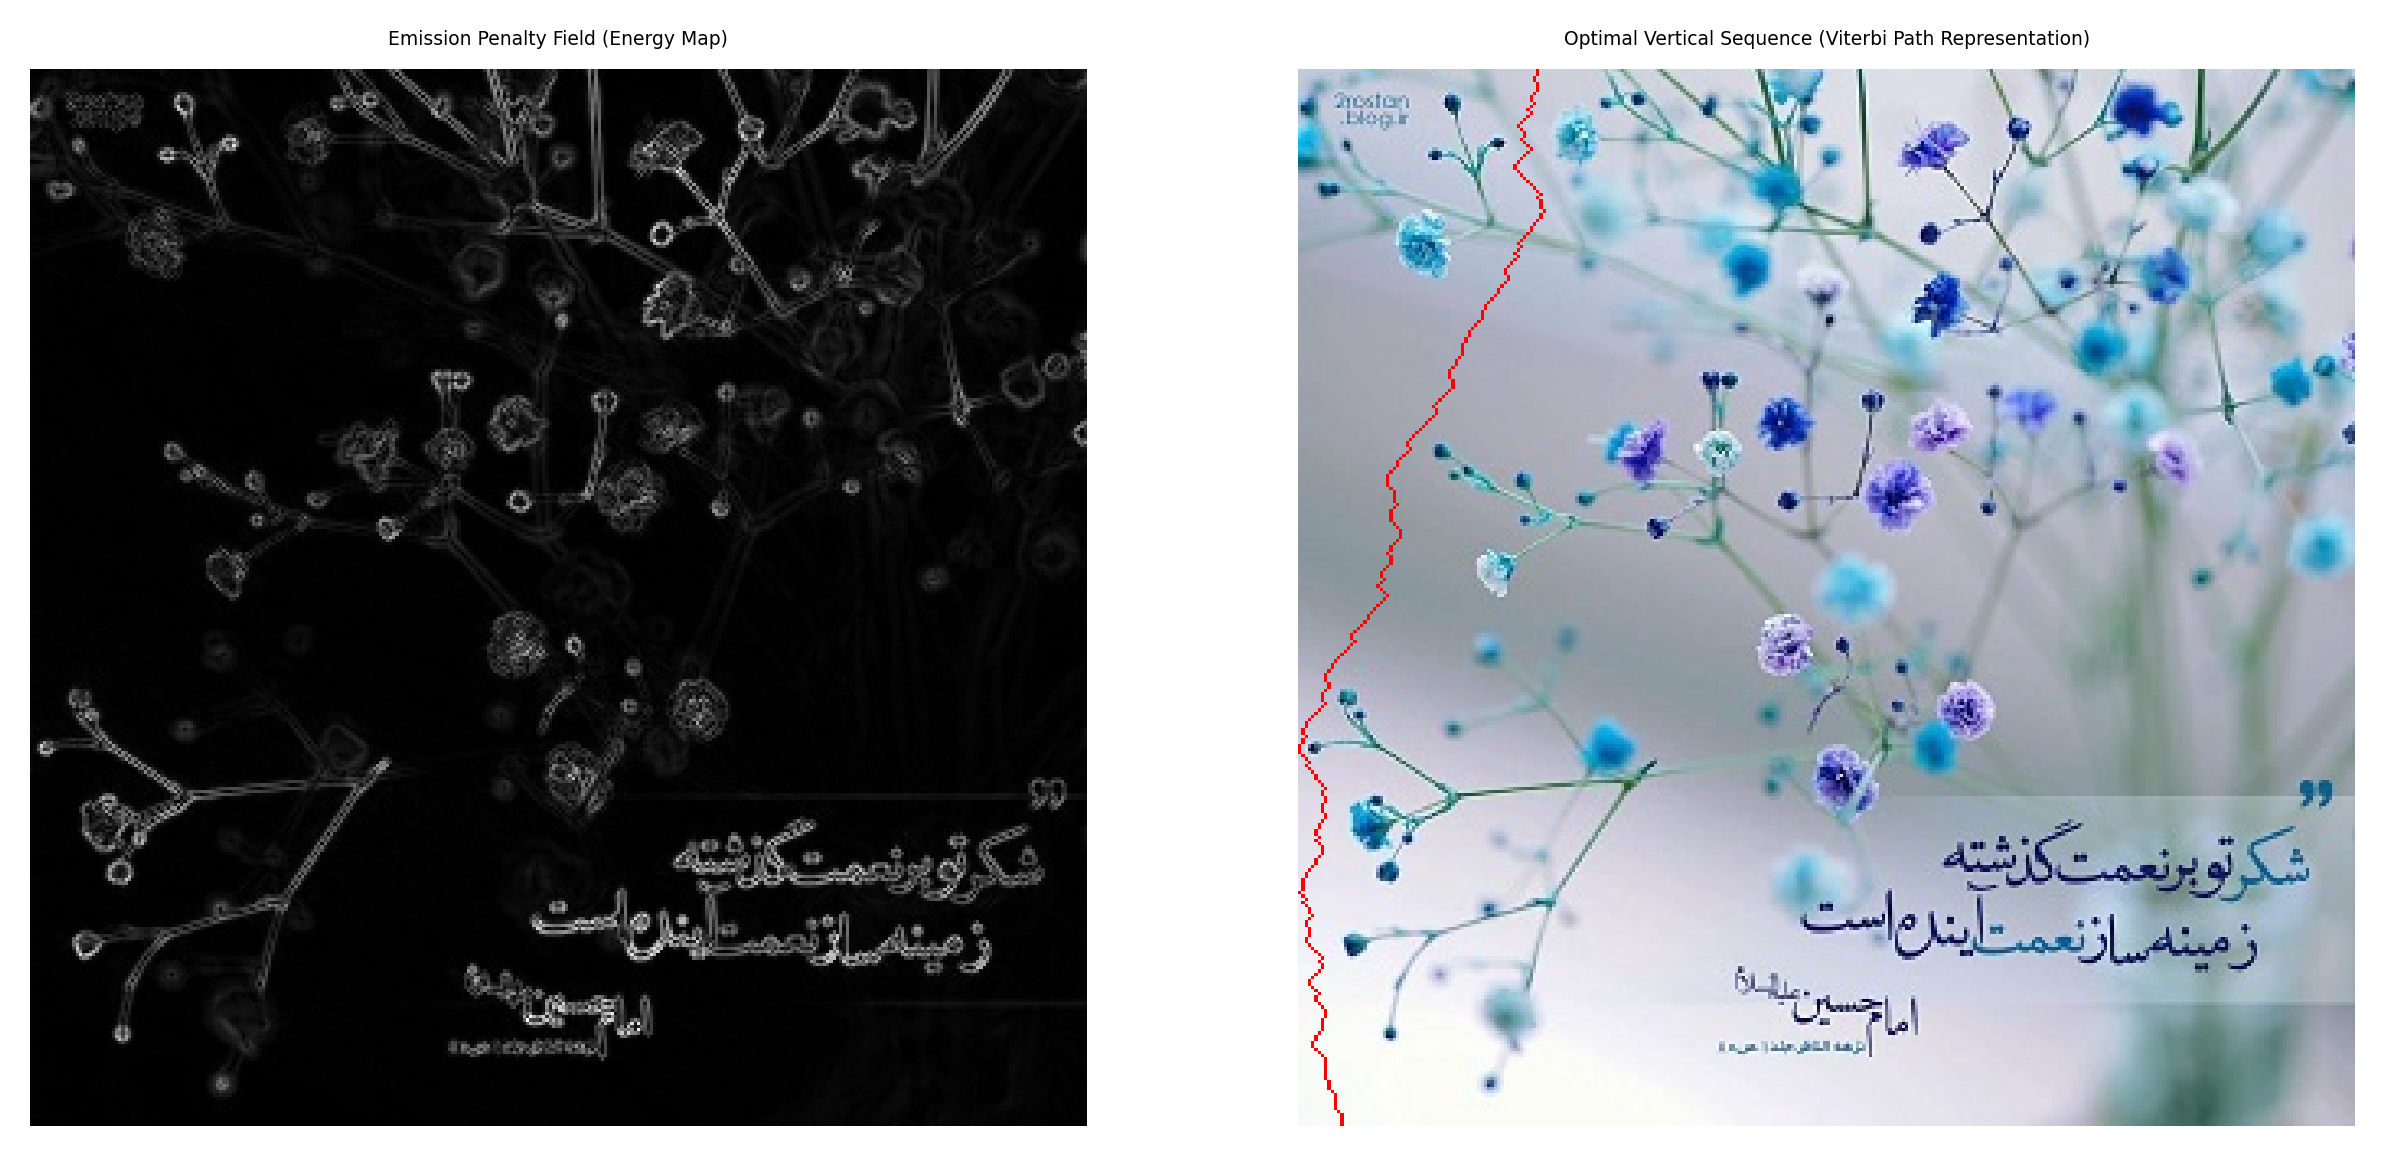

In [6]:
in_filename = "img/thanks.jpg"
img = imread(in_filename)

M, backtrack = minimum_vertical_seam(img)
seam_indices = find_optimal_vertical_seam(M, backtrack)

# Color the optimal path red on a copy of the transposed array
im_hs = img.copy()
for i, j in seam_indices:
    im_hs[i, j] = (255, 0, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Emission Penalty Field (Energy Map)")
plt.imshow(calc_energy(img), cmap='gray')

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Optimal Vertical Sequence (Viterbi Path Representation)")
plt.imshow(im_hs)
plt.show()

**Reduction Example:** Making an image smaller in width (540x540 → 540x400)

CPU times: total: 2min 17s
Wall time: 2min 46s


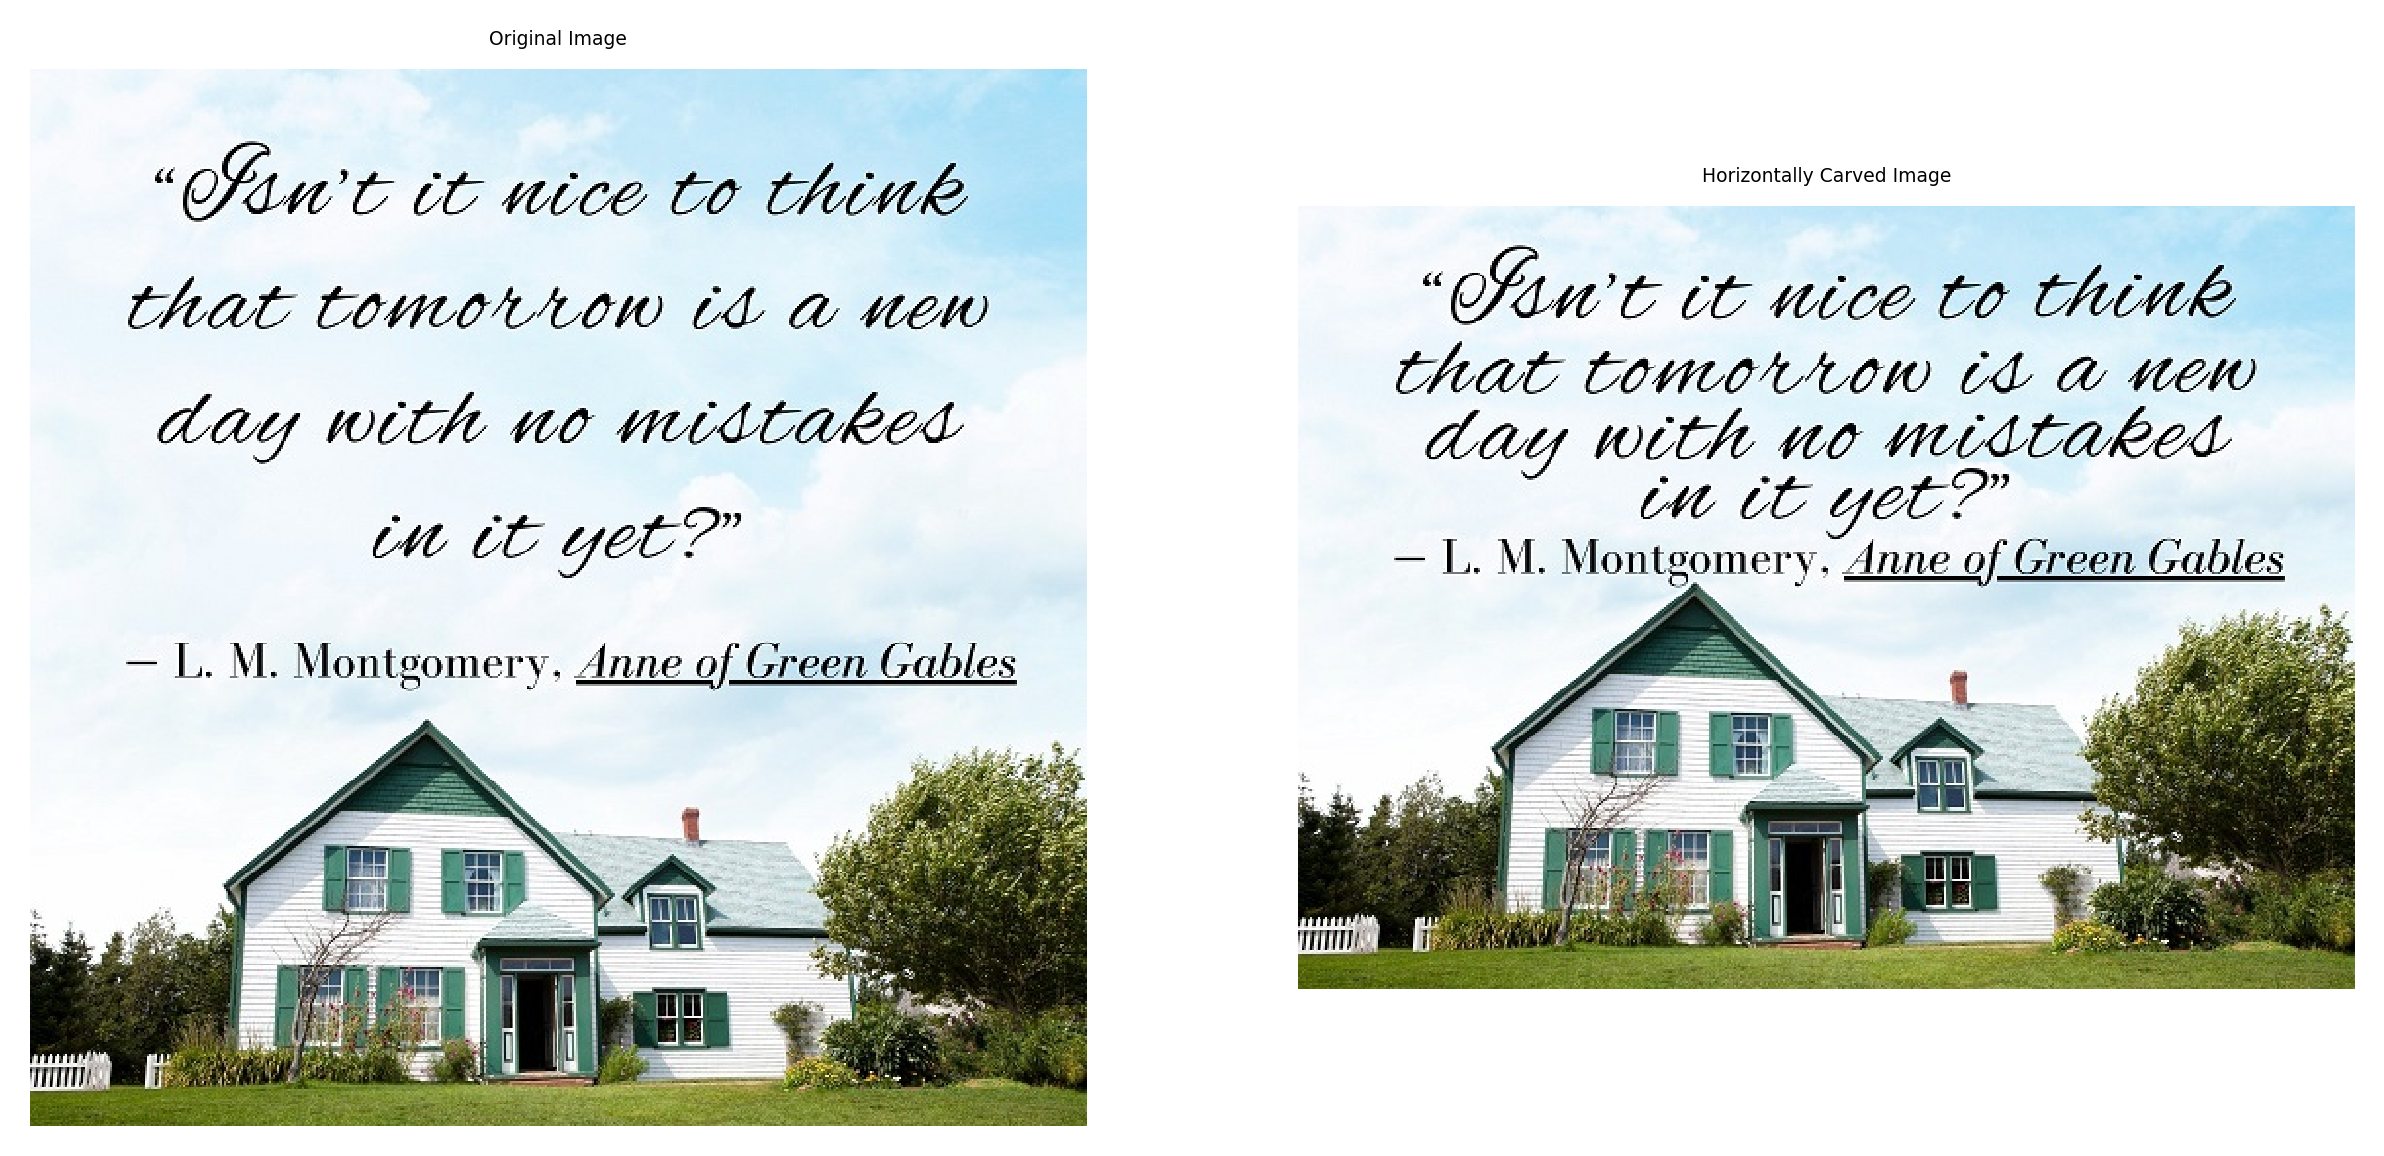

In [7]:
%%time
in_filename = "img/MistakeFreeTomorrow.jpg"
img = imread(in_filename)

# Carve out 140 horizontal lines directly
out = crop_r(img, 140)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Horizontally Carved Image")
plt.imshow(out.astype(np.uint8))

## Viterbi Algorithm: Continue

Let's visit the forward formula in the context of the Viterbi algorithm for Hidden Markov Models (HMMs).

1. **Background**:
   - The Viterbi algorithm is used to find the most likely sequence of hidden states (states of an HMM) given a sequence of observations (emissions).
   - In an HMM, we have:
     - Hidden states: $S = \{1, 2, \ldots, N\}$ (where $N$ is the total number of states).
     - Observations: $O = \{o_1, o_2, \ldots, o_T\}$ (where $T$ is the length of the observation sequence).

2. **Forward Algorithm**:
   - The forward algorithm computes the probability of observing the partial sequence $o_1, o_2, \ldots, o_t$ up to time $t$ and being in state $j$ at time $t$. We denote this as $\alpha_t(j)$.
   - The formula for $\alpha_{t+1}(j)$ is given by:

     $$ \alpha_{t+1}(j) = \left(\sum_{i=1}^N \alpha_t(i) \cdot a_{ij}\right) \cdot b_j(o_{t+1}) $$

     where:
     - $\alpha_t(i)$ represents the probability of being in state $i$ at time $t$.
     - $a_{ij}$ is the transition probability from state $i$ to state $j$.
     - $b_j(o_{t+1})$ is the emission probability of observing $o_{t+1}$ given that we are in state $j$.

3. **Initialization**:
   - To start the forward algorithm, we set $\alpha_0(j)$ for all states $j$ based on the initial state probabilities ($\pi_j$).

4. **Recursion**:
   - We compute $\alpha_{t+1}(j)$ for each time step $t$ by updating it based on the previous $\alpha_t(i)$ values and the transition and emission probabilities.

5. **Termination**:
   - The final probability of the entire observation sequence is given by $P(O|\lambda) = \sum_{i=1}^N \alpha_T(i)$.

The forward algorithm recursively computes the probabilities of being in different states at each time step, considering both transitions and emissions. 

![HMM-Model-Viterbi-Example](img/HMM-Model-Viterbi-Example.png)

Let's compute $\alpha_1(1)$, which represents the probability of starting in state 1 and observing $o_1$; using the given formula ($j=1, t=0, t+1=1$):

$$ \alpha_{1}(1) = \left(\sum_{i=1}^2 \alpha_t(i) a_{i1}\right) b_1(o_{1}) $$

$\alpha_1(1) = \alpha_0(1) a_{11} b_1(o_1) + \alpha_0(2) a_{21} b_1(o_1) = \pi_1 a_{11} b_1(o_1) + \pi_2 a_{21} b_1(o_1)$, 
where $\pi_j$ is the initial state probability for state j and $b_j(o_{t+1})$ is the emission probability for observation $o_{t+1}$ given that we are in state $j$.

![HMM-Model-Viterbi-Example-Solution](img/HMM-Model-Viterbi-Example-Sol.png)

In [8]:
from hidden_markov import hmm

Defining the HMM model of page 37 of [Dr. Veisi's slides](https://www.dropbox.com/scl/fi/9ez77b75eyw1al55k086s/StatNLP-Lecture6-HMM.pdf?rlkey=2vd1mfqwsrbu3ru4il6hta4m7&st=z2j7x6i4&dl=0)


In [9]:
# Define the Model
states = ("S1", "S2")
observations = ("A", "B")
start_prob_matrix = np.matrix([1, 0])
transition_matrix = np.matrix([[0.6, 0.4], [0, 1]])
emission_matrix = np.matrix([[0.8, 0.2], [0.3, 0.7]])

In [10]:
hmm_model = hmm(
    states, observations, start_prob_matrix, transition_matrix, emission_matrix
)

In [11]:
# The observations that we observe and feed to the model
obs1 = ("A", "A", "B")
hmm_model.forward_algo(obs1)

np.float64(0.22080000000000002)

In [12]:
hmm_model.viterbi(obs1)

['S1', 'S1', 'S2']

Define another model with dictionaries [GfG](https://www.geeksforgeeks.org/viterbi-algorithm-for-hidden-markov-models-hmms/)

In [13]:
# Define the Model
states = ("Rainy", "Sunny")
observations = ("walk", "shop", "clean")
start_probability = {"Rainy": 0.6, "Sunny": 0.4}
transition_probability = {
    "Rainy": {"Rainy": 0.7, "Sunny": 0.3},
    "Sunny": {"Rainy": 0.4, "Sunny": 0.6},
}
emission_probability = {
    "Rainy": {"walk": 0.1, "shop": 0.4, "clean": 0.5},
    "Sunny": {"walk": 0.6, "shop": 0.3, "clean": 0.1},
}

Converting dictionary to matrix

In [14]:
# Converting dictionary to matrix
n = len(states)

start_prob_matrix = np.matrix(list(start_probability.values()))
# print(start_prob_matrix)

transition_matrix = np.zeros((n, n))
for i, row_state in enumerate(states):
    for j, col_state in enumerate(states):
        transition_matrix[i, j] = transition_probability[row_state][col_state]
transition_matrix = np.matrix(transition_matrix)
# print(transition_matrix)

rows = len(emission_probability)
cols = len(emission_probability["Rainy"])
emission_matrix = np.zeros((rows, cols))

for i, state in enumerate(emission_probability):
    for j, activity in enumerate(emission_probability[state]):
        emission_matrix[i][j] = emission_probability[state][activity]
emission_matrix = np.matrix(emission_matrix)
# print(emission_matrix)

In [15]:
hmm_model = hmm(
    states, observations, start_prob_matrix, transition_matrix, emission_matrix
)

In [16]:
# The observations that we observe and feed to the model
obs1 = ("walk",  "shop", "clean")
hmm_model.forward_algo(obs1)

np.float64(0.033612)

In [17]:
hmm_model.viterbi(obs1)

['Sunny', 'Rainy', 'Rainy']

# Problem 3 — Learning (A Brief Note)

We will not cover Problem 3 in full, but it is worth understanding what it asks
and why it is hard.

Recall that in GMM we faced exactly the same situation: we had a model with hidden
structure (which Gaussian generated each point?) and needed to estimate its parameters
from data alone. Direct maximisation of the log-likelihood was intractable, so we
turned to the **EM algorithm** — iterating between a soft assignment of observations
to components (E-step) and a parameter update that maximises the expected
log-likelihood (M-step).

Problem 3 for HMMs is precisely the same idea, but now the hidden structure is a
*sequence* of states rather than a single latent label. The corresponding algorithm is
**Baum–Welch**, which is EM applied to HMMs. The E-step uses the Forward and Backward
variables (from Problem 1) to compute, for each time step, the soft probability that
the system was in each state — analogous to the responsibilities $r_{nk}$ in GMM. The
M-step then re-estimates $A$, $B$, and $\pi$ from those soft counts, exactly as GMM
re-estimated its means, covariances, and mixing weights. Like EM for GMMs,
Baum–Welch converges to a *local* maximum of the likelihood, so multiple random
initialisations are advisable in practice.

In short: if you understood why EM works for GMMs, you already understand the spirit
of Baum–Welch.

---

**References:**

1. [Speech and Language Processing](https://web.stanford.edu/~jurafsky/slp3/A.pdf), by Dan Jurafsky and James H. Martin. Stanford University, 2023.
2. Shai Avidan and Ariel Shamir. "Seam Carving for Content-Aware Image Resizing." 
   - [Paper](https://perso.crans.org/frenoy/matlab2012/seamcarving.pdf) 
   - [Github, Python](https://github.com/vivianhylee/seam-carving)
   - [GitHub (C++)](https://github.com/loc-trinh/seamCarving)
3. [Implementing Seam Carving with Python](https://karthikkaranth.me/blog/implementing-seam-carving-with-python/), by Karthik Karanth
4. [Intro to the Seam Carving Algorithm](https://ben-tanen.com/projects/2020/10/08/seam-carving-pt1.html), by Ben Tanen
5. [Intro to the Viterbi Algorithm](https://frazierbutler.medium.com/intro-to-the-viterbi-algorithm-8f41c3f43cf3), by Paul Butler

